In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10,6)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving student_performance.csv to student_performance.csv


In [ ]:
df = pd.read_csv('student_performance.csv')

print(df.head())
print(df.info())
print(df.describe())

  Student_ID  Gender  Attendance  Study_Hours  Math  Science  English  \
0     STU001    Male          56          6.2    66       58       48   
1     STU002    Male          98          6.2    46       84       42   
2     STU003    Male          60          2.5    99       33       75   
3     STU004    Male         100          5.5    88       58       68   
4     STU005  Female          55          6.3    55       84       61   

   Average_Score Result  
0          57.33   Pass  
1          57.33   Pass  
2          69.00   Pass  
3          71.33   Pass  
4          66.67   Pass  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Student_ID     300 non-null    object 
 1   Gender         300 non-null    object 
 2   Attendance     300 non-null    int64  
 3   Study_Hours    300 non-null    float64
 4   Math           300 non-null    i

In [ ]:
# Missing values
print(df.isnull().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Check data types
print(df.dtypes)

Student_ID       0
Gender           0
Attendance       0
Study_Hours      0
Math             0
Science          0
English          0
Average_Score    0
Result           0
dtype: int64
Student_ID        object
Gender            object
Attendance         int64
Study_Hours      float64
Math               int64
Science            int64
English            int64
Average_Score    float64
Result            object
dtype: object


In [ ]:
df['Average_Score'] = (
    df['Math'] +
    df['Science'] +
    df['English']
) / 3

In [ ]:
df['Result'] = np.where(
    df['Average_Score'] >= 40,
    'Pass',
    'Fail'
)

In [ ]:
total_students = len(df)

pass_percentage = (
    (df['Result'] == 'Pass').mean() * 100
)

average_score = df['Average_Score'].mean()

print("Total Students:", total_students)
print("Pass Percentage:", round(pass_percentage,2))
print("Average Score:", round(average_score,2))

Total Students: 300
Pass Percentage: 100.0
Average Score: 68.56


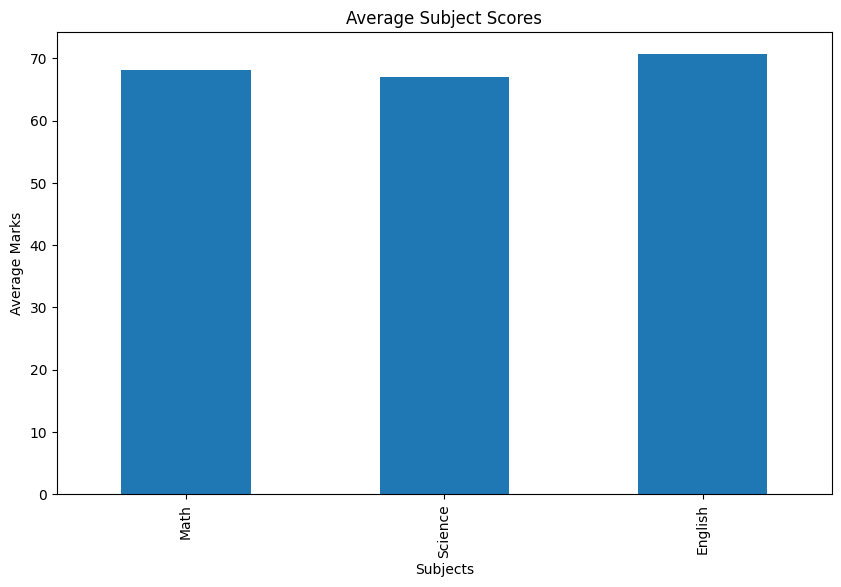

In [ ]:
subject_avg = df[['Math','Science','English']].mean()

subject_avg.plot(kind='bar')

plt.title("Average Subject Scores")
plt.xlabel("Subjects")
plt.ylabel("Average Marks")

plt.show()

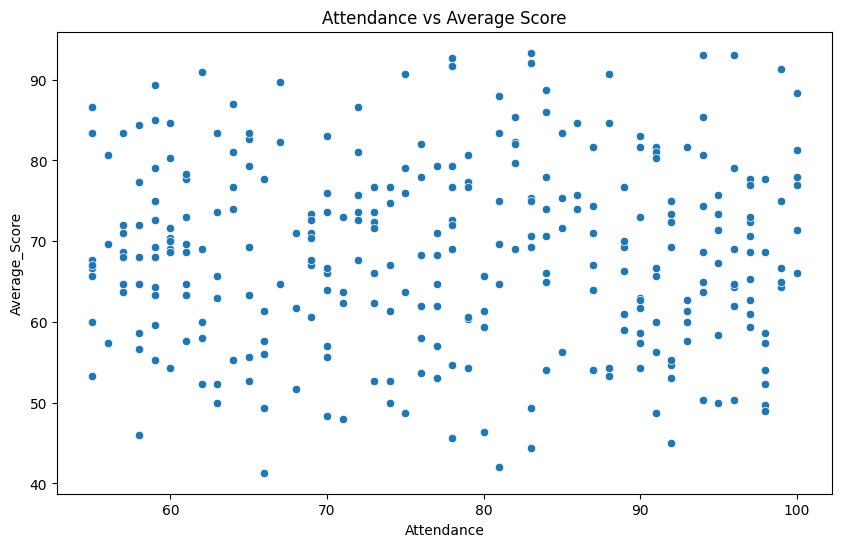

In [ ]:
sns.scatterplot(
    x='Attendance',
    y='Average_Score',
    data=df
)

plt.title("Attendance vs Average Score")

plt.show()

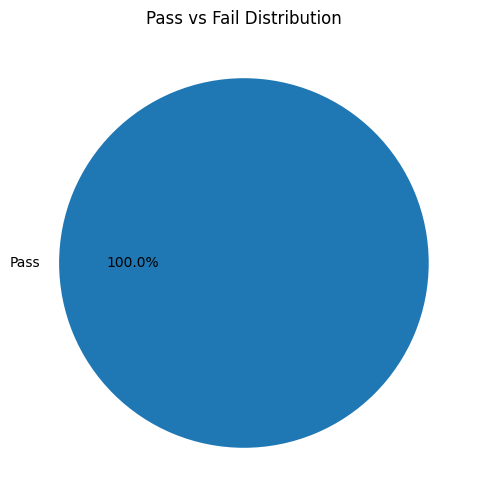

In [ ]:
df['Result'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Pass vs Fail Distribution")

plt.ylabel("")

plt.show()

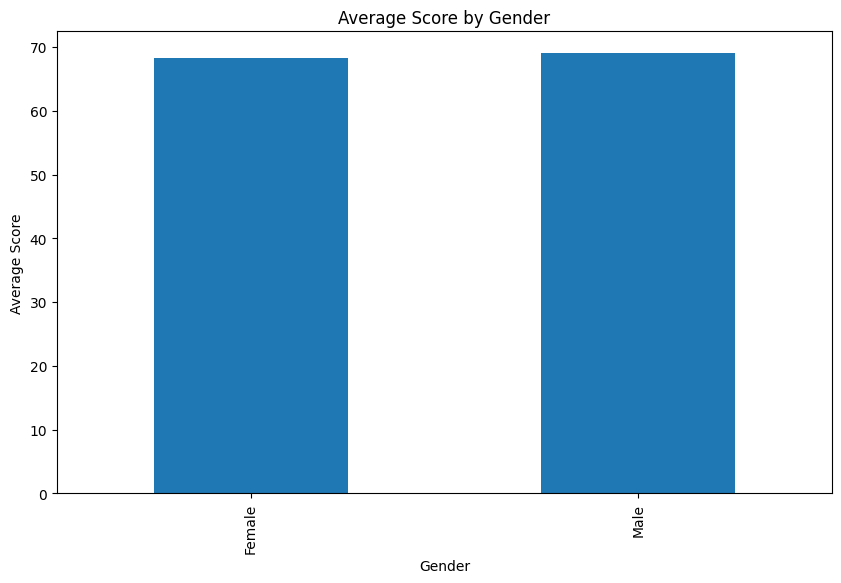

In [ ]:
gender_avg = df.groupby('Gender')['Average_Score'].mean()

gender_avg.plot(kind='bar')

plt.title("Average Score by Gender")
plt.ylabel("Average Score")

plt.show()

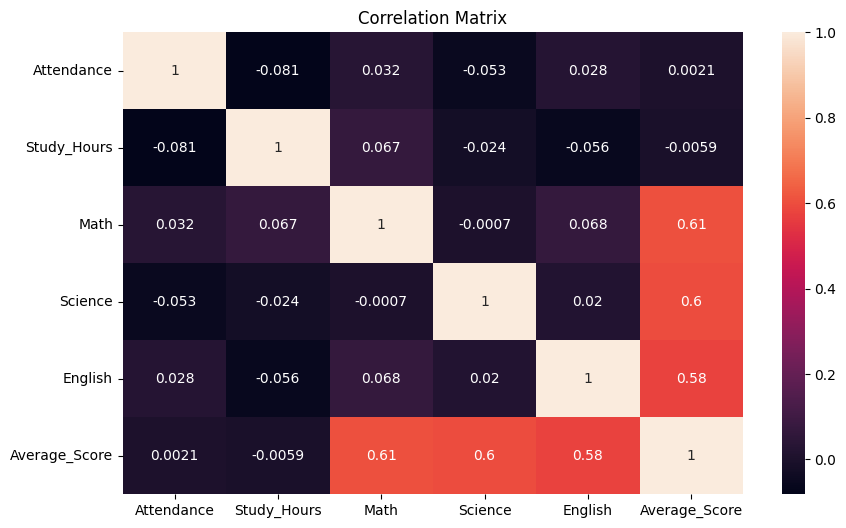

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

sns.heatmap(correlation, annot=True)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
attendance_corr = df['Attendance'].corr(df['Average_Score'])

print("Correlation:", attendance_corr)

Correlation: 0.0020890336772851122


In [ ]:
top_students = df.sort_values(
    by='Average_Score',
    ascending=False
).head(10)

print(top_students)

    Student_ID  Gender  Attendance  Study_Hours  Math  Science  English  \
78      STU079  Female          83          5.7   100       90       90   
194     STU195  Female          96          1.7    97       82      100   
76      STU077    Male          94          5.0    86      100       93   
196     STU197    Male          78          1.7    82       99       97   
86      STU087  Female          83          5.3    99       84       93   
52      STU053    Male          78          3.0    91       99       85   
118     STU119    Male          99          4.3    97       87       90   
147     STU148  Female          62          7.8    86       95       92   
149     STU150    Male          88          3.5    98       86       88   
286     STU287    Male          75          7.5   100       80       92   

     Average_Score Result  
78       93.333333   Pass  
194      93.000000   Pass  
76       93.000000   Pass  
196      92.666667   Pass  
86       92.000000   Pass  
52    

In [ ]:
import os

# Create folder
os.makedirs('visualizations', exist_ok=True)

# Save chart
plt.savefig('visualizations/attendance_vs_score.png')

print("Chart saved successfully!")

Chart saved successfully!


<Figure size 1000x600 with 0 Axes>

In [ ]:
import os

os.makedirs('reports', exist_ok=True)

report = f"""
STUDENT PERFORMANCE REPORT
==========================

Total Students: {total_students}

Pass Percentage: {round(pass_percentage,2)}%

Average Score: {round(average_score,2)}

KEY INSIGHTS:
1. High attendance improves academic performance.
2. Study hours strongly affect scores.
3. Science subject requires additional support.
"""

with open(
    'reports/student_report.txt',
    'w'
) as file:

    file.write(report)

print("Report Generated Successfully")

Report Generated Successfully


In [ ]:
def assign_grade(score):

    if score >= 90:
        return 'A'

    elif score >= 75:
        return 'B'

    elif score >= 60:
        return 'C'

    else:
        return 'D'

df['Grade'] = df['Average_Score'].apply(assign_grade)

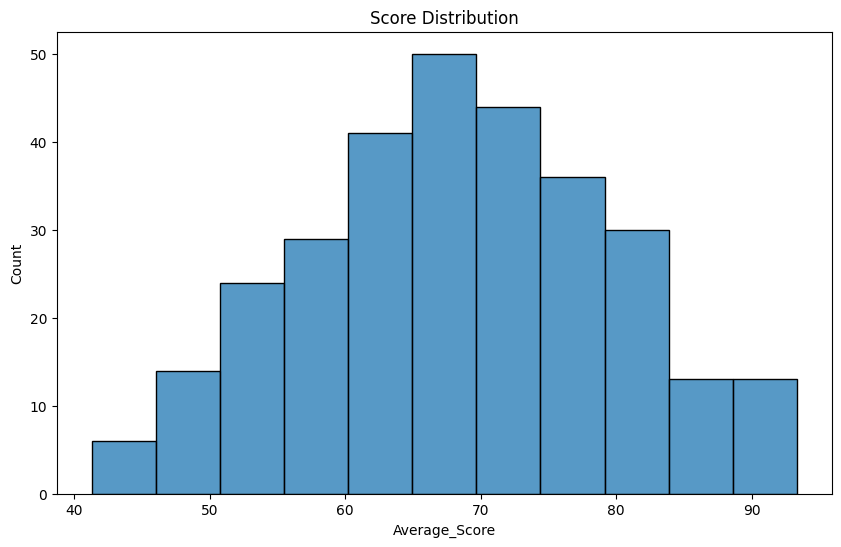

In [ ]:
sns.histplot(df['Average_Score'])

plt.title("Score Distribution")

plt.show()

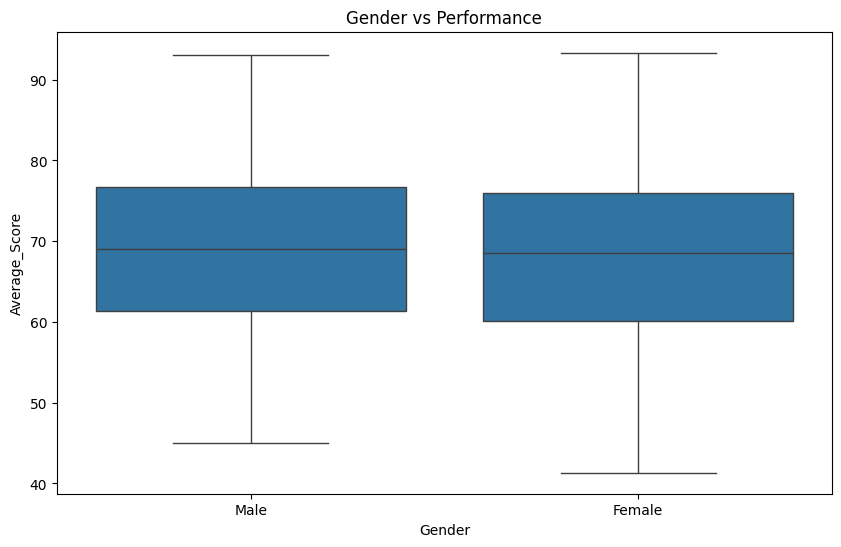

In [ ]:
sns.boxplot(
    x='Gender',
    y='Average_Score',
    data=df
)

plt.title("Gender vs Performance")

plt.show()